<a href="https://colab.research.google.com/github/SoumyadeepChattopadhyay2004/Student-Dropout-Prediction-System/blob/main/Student_Dropout_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [177]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
df = pd.read_csv("/content/student-mat.csv", sep=';')

print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


In [179]:
df['dropout'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)

df.drop(['G1','G2','G3'], axis=1, inplace=True)

print(df['dropout'].value_counts())

dropout
0    265
1    130
Name: count, dtype: int64


In [180]:
df = pd.get_dummies(df, drop_first=True)

In [181]:
X = df.drop('dropout', axis=1)
y = df['dropout']

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [183]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [184]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [185]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy:
0.7088607594936709

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.87      0.80        52
           1       0.61      0.41      0.49        27

    accuracy                           0.71        79
   macro avg       0.67      0.64      0.64        79
weighted avg       0.69      0.71      0.69        79


Confusion Matrix
[[45  7]
 [16 11]]


In [186]:
tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [187]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_tree))

print("\nClassification Report")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy:
0.759493670886076

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.98      0.84        52
           1       0.90      0.33      0.49        27

    accuracy                           0.76        79
   macro avg       0.82      0.66      0.66        79
weighted avg       0.79      0.76      0.72        79


Confusion Matrix
[[51  1]
 [18  9]]


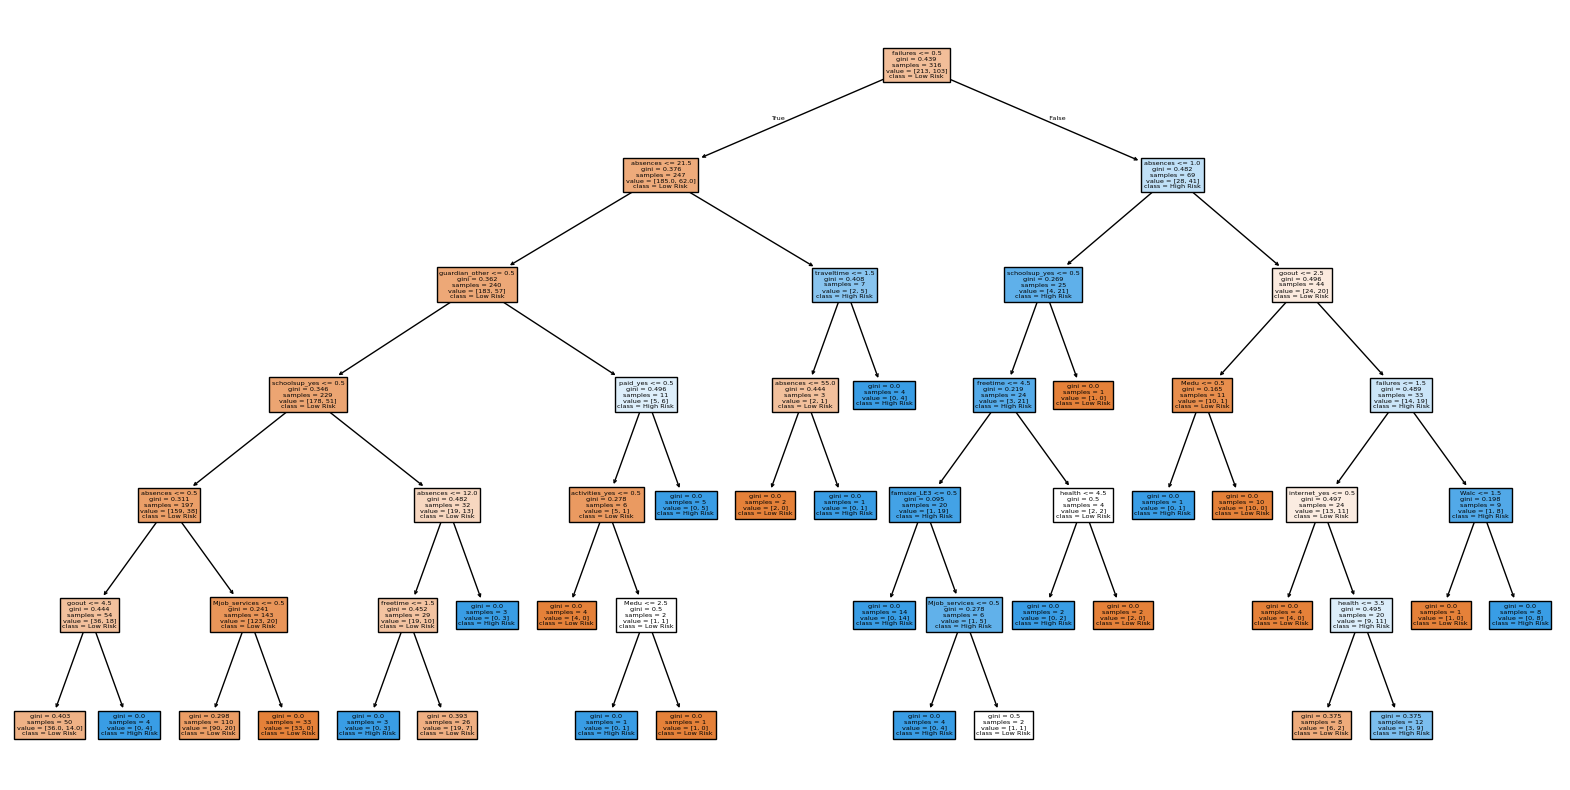

In [188]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Low Risk','High Risk'],
    filled=True
)

plt.show()

In [189]:
importance = tree_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

failures          0.225047
absences          0.214637
goout             0.114801
health            0.065441
freetime          0.062803
schoolsup_yes     0.059138
paid_yes          0.056337
Medu              0.041915
Mjob_services     0.034877
guardian_other    0.032521
dtype: float64


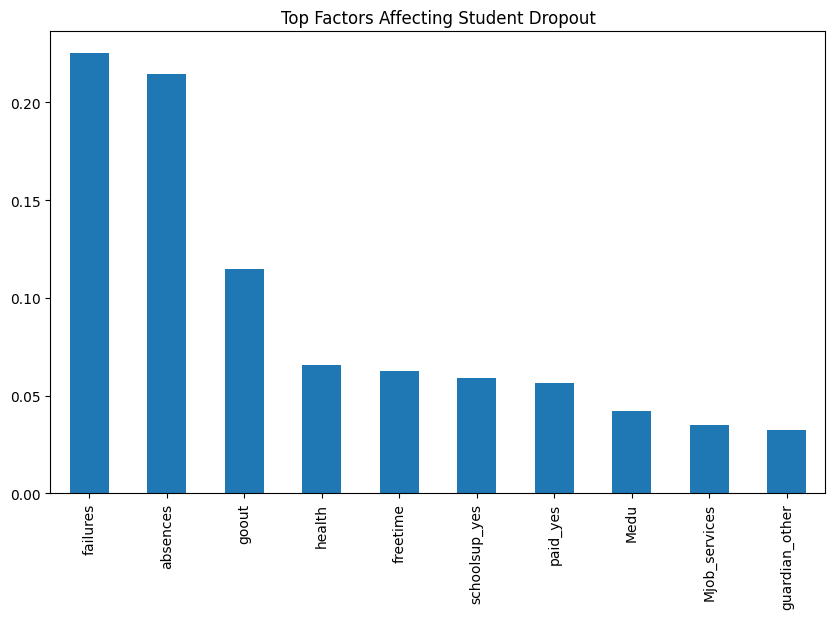

In [190]:
plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind='bar')

plt.title("Top Factors Affecting Student Dropout")

plt.show()

In [191]:
sample_student = X.iloc[0:1]

prediction = log_model.predict(scaler.transform(sample_student))
probability = log_model.predict_proba(scaler.transform(sample_student))

print("Prediction:", prediction)
print("Dropout Probability:", probability)

Prediction: [0]
Dropout Probability: [[0.70293159 0.29706841]]


In [192]:
risk_score = probability[0][1] * 100

print("Risk Score:", risk_score)

if risk_score < 30:
    print("Low Risk")
elif risk_score < 60:
    print("Moderate Risk")
else:
    print("High Dropout Risk")

Risk Score: 29.706840573054038
Low Risk
